<a href="https://colab.research.google.com/github/HelloPenguin1/Spinal_Metastasis_Classification_TCIA/blob/main/Model_Train_Baseline2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install -q monai SimpleITK nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 15.8 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight

from monai.transforms import (
    Compose,
    RandFlip,
    RandRotate,
    RandZoom,
)

import SimpleITK as sitk
import nibabel as nib
from monai.data import set_track_meta

In [6]:
# use 3 middle slcies of each volume

In [7]:
set_track_meta(False)

In [8]:
TENSOR_DIR = "/content/drive/MyDrive/TCIA_Original/tensors"

In [9]:
df = pd.read_csv('/content/labels.csv')
df['Patient_ID'] = df['filename'].apply(lambda x: x.split('_')[0])
df['Vertebra_Level'] = df['filename'].apply(lambda x: x.split('_')[1].replace('.npy', ''))

In [10]:
#Label Mapping
label_mapping = {'No Lesion': 0, 'Lytic': 1, 'Blastic': 2, 'Mixed': 3}
df['label_int'] = df['label'].map(label_mapping)

Idential 3D Augmentation as 3D Baseline

In [11]:
train_transforms = Compose([
    # 1. Left/Right Flip
    RandFlip(prob=0.5, spatial_axis=2),

    # 2. Subtle Rotations
    RandRotate(range_x=0.17, range_y=0.17, range_z=0.17, prob=0.5),

    # 3. Subtle Zooming
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5)
])

Only extracting the middle slices

In [12]:
def parse_npy_with_monai_2d(filename, label, is_training):
    filepath = os.path.join(TENSOR_DIR, filename.decode('utf-8'))
    tensor = np.load(filepath).astype(np.float32)

    if is_training:
        tensor = np.expand_dims(tensor, axis=0)

        # Apply biological augmentations to the whole 3D volume
        tensor = train_transforms(tensor)

        tensor = np.asarray(tensor)
        tensor = np.moveaxis(tensor, 0, -1) # Shape: (64, 64, 64, 1)
    else:
        tensor = np.expand_dims(tensor, axis=-1)

    # THE 2.5D CONVERSION: Extract slices 31, 32, and 33 and drop the blank 4th axis
    tensor_2d = tensor[:, :, 31:34, 0]

    return tensor_2d, label

Dataset creation for optimized inoput

In [13]:
def tf_load_train_2d(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda f, l: parse_npy_with_monai_2d(f, l, is_training=True),
        inp=[filename, label], Tout=[tf.float32, tf.int32]
    )
    # SHAPE CHANGED: Now expects 3 channels instead of 64 slices
    tensor.set_shape((64, 64, 3))
    label.set_shape(())
    return tensor, tf.cast(label, tf.int32)

def tf_load_val_2d(filename, label):
    tensor, label = tf.numpy_function(
        func=lambda f, l: parse_npy_with_monai_2d(f, l, is_training=False),
        inp=[filename, label], Tout=[tf.float32, tf.int32]
    )
    # SHAPE CHANGED: Now expects 3 channels instead of 64 slices
    tensor.set_shape((64, 64, 3))
    label.set_shape(())
    return tensor, tf.cast(label, tf.int32)

In [14]:
def create_dataset_2d(dataframe, batch_size=8, is_training=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe['filename'].values, dataframe['label_int'].values))

    if is_training:
        ds = ds.shuffle(buffer_size=len(dataframe))
        ds = ds.map(tf_load_train_2d, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(tf_load_val_2d, num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

Model Definition - ResNET

In [19]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

In [31]:

def build_resnet_2d_baseline(input_shape=(64, 64, 3), num_classes=4):
    print("Loading Pre-trained ResNet50...")

    # 1. Load the core ResNet50 model (without the 1000-class ImageNet head)
    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=input_shape)

    # 2. FREEZE THE BASE MODEL (Critical for small medical datasets)
    base_model.trainable = False

    # 3. Build the custom medical classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x) # Flattens the 2D feature maps safely
    x = Dropout(0.5)(x)             # Added protection against memorization

    # Final 4-class output layer
    predictions = Dense(num_classes, activation='softmax')(x)

    # 4. Stitch it together
    model = Model(inputs=base_model.input, outputs=predictions)

    # Compile exactly the same as your 3D model
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

# To view the architecture:
# model_2d = build_resnet_2d_baseline()
# model_2d.summary()

In [32]:
model_2d = build_resnet_2d_baseline()
model_2d.summary()

Loading Pre-trained ResNet50...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 70, 70, 3) │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 32, 32,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 32, 32,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 32, 32,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 34, 34,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 16, 16,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 16, 16,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 16, 16,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 16, 16,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 16, 16,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 16, 16,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 16, 16,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 16, 16,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 16, 16,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 16, 16,    │      1,024 │ conv2_block1_3_c

 Total params: 23,595,908 (90.01 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Model Training

In [17]:
K_FOLDS = 5
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_metrics = []
oof_true_labels = []  # To store actual labels across all folds
oof_predictions = []  # <To store model predictions across all folds

In [34]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")
    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    # 1. Compute dynamic weights for this fold train set
    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    # 2. Build TF Datasets
    train_ds = create_dataset_2d(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset_2d(val_df, batch_size=8, is_training=False)

    # 3. Build a new model and prevent weight leaks
    tf.keras.backend.clear_session()
    model = build_resnet_2d_baseline()

    # 4. Model train with few initial epochs for testing
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights_dict,
        verbose=1
    )

    # 5. final validation accuracy
    final_val_acc = history.history['val_accuracy'][-1]
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Final Validation Accuracy: {final_val_acc:.4f}")

# 6. CAPTURE OUT-OF-FOLD (OOF) PREDICTIONS
    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        oof_true_labels.extend(labels.numpy())
        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)

               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
Loading Pre-trained ResNet50...
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.2140 - loss: 1.6851 - val_accuracy: 0.2174 - val_loss: 1.3558
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 224ms/step - accuracy: 0.2716 - loss: 1.4248 - val_accuracy: 0.3913 - val_loss: 1.3790
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.2510 - loss: 1.4525 - val_accuracy: 0.4348 - val_loss: 1.3535
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - accuracy: 0.3004 - loss: 1.3629 - val_accuracy: 0.4348 - val_loss: 1.3301
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 152ms/step - accuracy: 0.3745 - loss: 1.3313 - val_accuracy: 0.4348 - val_loss: 1.3202
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.3663 - loss: 1.2969 - val_accuracy: 0.4348 - val_loss: 1.3174
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.3786 - loss: 1.3200 - val_accuracy: 0.43

               FOLD 5
Training on 42 patients (239 volumes)
Testing on 10 patients (50 volumes)
Loading Pre-trained ResNet50...
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 29s 539ms/step - accuracy: 0.2929 - loss: 1.5843 - val_accuracy: 0.1400 - val_loss: 1.3964
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 159ms/step - accuracy: 0.2887 - loss: 1.4547 - val_accuracy: 0.2000 - val_loss: 1.3875
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 194ms/step - accuracy: 0.2803 - loss: 1.3993 - val_accuracy: 0.2600 - val_loss: 1.3800
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - accuracy: 0.3598 - loss: 1.3720 - val_accuracy: 0.1200 - val_loss: 1.4296
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 163ms/step - accuracy: 0.3515 - loss: 1.3546 - val_accuracy: 0.3400 - val_loss: 1.3714
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.3431 - loss: 1.3306 - val_accuracy: 0.3800 - val_loss: 1.3958
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 157ms/step - accuracy: 0.4561 - loss: 1.2737 - val_accuracy: 0

In [35]:
fold_metrics

[0.43478259444236755,
 0.45348837971687317,
 0.2954545319080353,
 0.2857142984867096,
 0.18000000715255737]

In [36]:
mean_val_accuracy = sum(fold_metrics)/5
mean_val_accuracy

0.32988796234130857


   CROSS-VALIDATION COMPLETE

     2D BASELINE REPORT
              precision    recall  f1-score   support

   No Lesion       0.50      0.45      0.47       116
       Lytic       0.07      0.12      0.09        42
     Blastic       0.16      0.18      0.17        55
       Mixed       0.59      0.42      0.49        76

    accuracy                           0.34       289
   macro avg       0.33      0.29      0.31       289
weighted avg       0.40      0.34      0.37       289



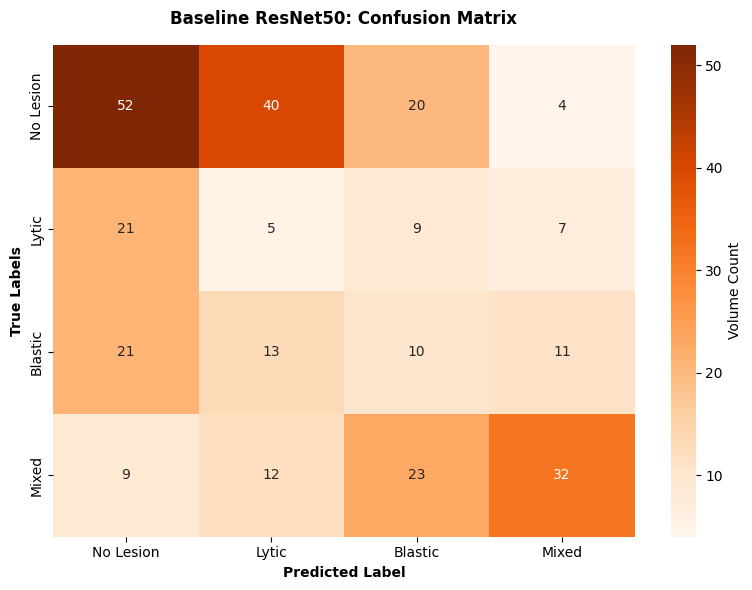

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ==========================================
# FINAL PUBLICATION METRICS & VISUALIZATION (2.5D BASELINE)
# ==========================================
print(f"\n{'='*40}")
print("   CROSS-VALIDATION COMPLETE")
print(f"{'='*40}")

# 1. Process the aggregated Out-Of-Fold predictions
oof_true_labels = np.array(oof_true_labels)
# ResNet outputs probabilities; grab the highest probability for the final class prediction
oof_pred_classes = np.argmax(oof_predictions, axis=1)
class_names = ['No Lesion', 'Lytic', 'Blastic', 'Mixed']

# 2. Print the text-based classification report
print("\n" + "="*60)
print("     2D BASELINE REPORT")
print("="*60)
print(classification_report(oof_true_labels, oof_pred_classes, target_names=class_names))

# 3. Generate the Master Confusion Matrix
cm = confusion_matrix(oof_true_labels, oof_pred_classes)

plt.figure(figsize=(8, 6))
# Using 'Oranges' to visually distinguish the 2D baseline from the 3D 'Blues'
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Volume Count'})

plt.title('Baseline ResNet50: Confusion Matrix', pad=15, fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=10, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

Resnet with some fine tuning

In [15]:
def build_resnet_2d_baseline(input_shape=(64, 64, 3), num_classes=4):
    base_model = ResNet50(weights='imagenet',
                          include_top=False,
                          input_shape=input_shape)

    # Unfreeze the very top layers (Stage 5) so it can adapt to CT scans
    base_model.trainable = True
    for layer in base_model.layers[:-15]: # Freeze everything except the last 15 layers
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # CRITICAL: Drop learning rate significantly for fine-tuning (1e-5)
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [20]:
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['label_int'], df['Patient_ID'])):
    print(f"               FOLD {fold + 1}")
    print(f"{'='*40}")

    train_df = df.iloc[train_idx].copy()
    val_df = df.iloc[val_idx].copy()

    print(f"Training on {train_df['Patient_ID'].nunique()} patients ({len(train_df)} volumes)")
    print(f"Testing on {val_df['Patient_ID'].nunique()} patients ({len(val_df)} volumes)")
    train_df['label_int'] = train_df['label_int'].astype(np.int32)
    val_df['label_int'] = val_df['label_int'].astype(np.int32)

    weights = compute_class_weight('balanced', classes=np.unique(train_df['label_int']), y=train_df['label_int'])
    class_weights_dict = {i: weight for i, weight in enumerate(weights)}

    train_ds = create_dataset_2d(train_df, batch_size=8, is_training=True)
    val_ds = create_dataset_2d(val_df, batch_size=8, is_training=False)

    tf.keras.backend.clear_session()
    model = build_resnet_2d_baseline()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        class_weight=class_weights_dict,
        verbose=1
    )

    final_val_acc = history.history['val_accuracy'][-1]
    fold_metrics.append(final_val_acc)
    print(f"Fold {fold + 1} Final Validation Accuracy: {final_val_acc:.4f}")

    print(f"Gathering predictions for Fold {fold + 1} validation patients...")
    for images, labels in val_ds:
        oof_true_labels.extend(labels.numpy())
        preds = model.predict(images, verbose=0)
        oof_predictions.extend(preds)

               FOLD 1
Training on 39 patients (243 volumes)
Testing on 13 patients (46 volumes)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.3498 - loss: 1.6682 - val_accuracy: 0.2609 - val_loss: 1.3880
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.3004 - loss: 1.6958 - val_accuracy: 0.2174 - val_loss: 1.3780
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 172ms/step - accuracy: 0.2922 - loss: 1.5255 - val_accuracy: 0.1957 - val_loss: 1.3647
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 10s 179ms/step - accuracy: 0.3251 - loss: 1.5420 - val_accuracy: 0.1957 - val_loss: 1.3604
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 11s 196ms/step - accuracy: 0.3704 - loss: 1.4499 - val_accuracy: 0.1957 - val_loss: 1.3469
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 298ms/step - accuracy: 0.3457 - loss: 1.4742 - val_accuracy: 0.1957 - val_loss: 1.3376
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 197ms/step - accuracy: 0.3580 - loss: 1.386

               FOLD 5
Training on 42 patients (239 volumes)
Testing on 10 patients (50 volumes)
Epoch 1/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 30s 538ms/step - accuracy: 0.3515 - loss: 1.8045 - val_accuracy: 0.2200 - val_loss: 1.5825
Epoch 2/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 208ms/step - accuracy: 0.3389 - loss: 1.5291 - val_accuracy: 0.2200 - val_loss: 1.5969
Epoch 3/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 133ms/step - accuracy: 0.3598 - loss: 1.5414 - val_accuracy: 0.2200 - val_loss: 1.6105
Epoch 4/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 137ms/step - accuracy: 0.3640 - loss: 1.5603 - val_accuracy: 0.2200 - val_loss: 1.6130
Epoch 5/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 181ms/step - accuracy: 0.4393 - loss: 1.4964 - val_accuracy: 0.2600 - val_loss: 1.6130
Epoch 6/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 158ms/step - accuracy: 0.4561 - loss: 1.3942 - val_accuracy: 0.2200 - val_loss: 1.6377
Epoch 7/15
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 155ms/step - accuracy: 0.4351 - loss: 1.3159 - val_accuracy: 0.2600 - val_loss: 1.6559
Epoch 8

In [24]:
mean_val_accuracy = sum(fold_metrics)/5
mean_val_accuracy

0.32745731472969053

2D BASELINE REPORT
              precision    recall  f1-score   support

   No Lesion       0.48      0.43      0.45       116
       Lytic       0.11      0.21      0.15        42
     Blastic       0.25      0.27      0.26        55
       Mixed       0.48      0.28      0.35        76

    accuracy                           0.33       289
   macro avg       0.33      0.30      0.30       289
weighted avg       0.38      0.33      0.35       289



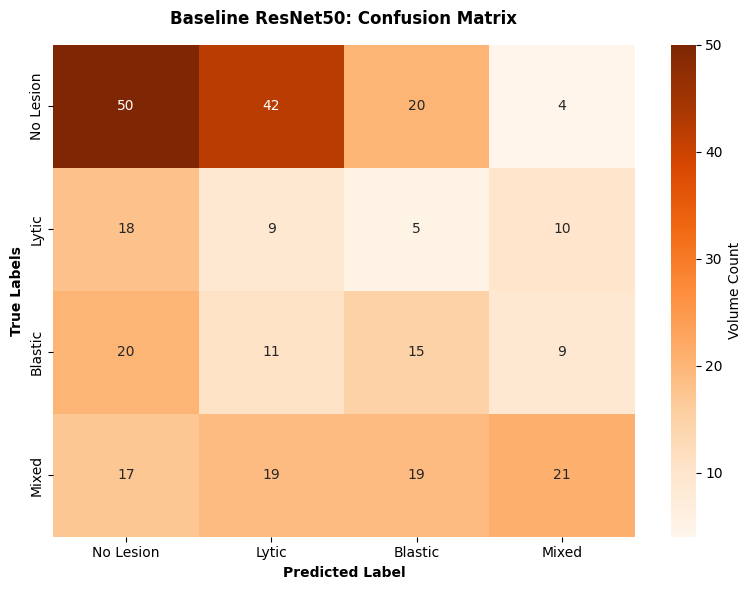

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


oof_true_labels = np.array(oof_true_labels)
oof_pred_classes = np.argmax(oof_predictions, axis=1)
class_names = ['No Lesion', 'Lytic', 'Blastic', 'Mixed']

print("2D BASELINE REPORT")
print(classification_report(oof_true_labels, oof_pred_classes, target_names=class_names))

cm = confusion_matrix(oof_true_labels, oof_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Volume Count'})

plt.title('Baseline ResNet50: Confusion Matrix', pad=15, fontsize=12, fontweight='bold')
plt.ylabel('True Labels', fontsize=10, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()